# Week 1: Baseline Attention Analysis for Target Application Scenarios

## Project Context

This project investigates a Python-embedded domain-specific language (DSL) for memory-efficient attention computation. Rather than attempting to outperform state-of-the-art attention kernels in the general case, this project focuses on application scenarios where fixed-function implementations may be less flexible or less effective.

## Week 1 Goals

The goals of this notebook are:

1. Define the three target application scenarios:
   - Multi-tenant LLM serving
   - Streaming inference
   - Long-context systems
2. Implement a baseline scaled dot-product attention mechanism in PyTorch
3. Build baseline experiments that expose inefficiencies in these scenarios
4. Collect initial runtime and memory results to motivate later DSL-based transformations

## Motivation

Prior work such as FlashAttention shows that tiled, IO-aware computation can significantly improve memory efficiency for attention. However, many existing solutions are implemented as fixed-function, hardware-specialized kernels. This project focuses on settings where a programmable, scenario-aware abstraction may offer additional value.

In [1]:
import math
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


## Target Application Scenarios

This project focuses on three scenarios where attention execution may benefit from customization:

### 1. Multi-tenant LLM serving
Requests from multiple users may have different sequence lengths, latency requirements, and memory demands. Static execution strategies may waste computation or memory when handling heterogeneous workloads.

### 2. Streaming inference
In streaming settings, tokens arrive incrementally over time. Attention computation may need to be performed repeatedly as the context grows, which creates opportunities for more adaptive execution strategies.

### 3. Long-context systems
As sequence lengths increase, standard attention becomes increasingly expensive because it materializes large intermediate matrices. This creates significant runtime and memory pressure.

The purpose of Week 1 is not yet to optimize these scenarios, but to build baseline evidence that they create distinct challenges for standard attention implementations.

## Baseline Attention Implementation

We begin with a standard scaled dot-product attention implementation in PyTorch. This serves as the reference baseline for all scenario-specific experiments.

In [3]:
def baseline_attention(Q, K, V):
    """
    Standard scaled dot-product attention.

    Q: (B, N, D)
    K: (B, N, D)
    V: (B, N, D)

    Returns:
        output: (B, N, D)
    """
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    attn = torch.softmax(scores, dim=-1)
    output = torch.matmul(attn, V)
    return output

In [4]:
B, N, D = 2, 128, 64

Q = torch.randn(B, N, D, device=device)
K = torch.randn(B, N, D, device=device)
V = torch.randn(B, N, D, device=device)

out = baseline_attention(Q, K, V)
print("Output shape:", out.shape)

Output shape: torch.Size([2, 128, 64])


## Benchmarking Utilities

The following helper functions measure average runtime and peak memory usage for the baseline implementation.

In [5]:
def benchmark_runtime(fn, Q, K, V, num_warmup=5, num_runs=20):
    for _ in range(num_warmup):
        _ = fn(Q, K, V)

    if device == "cuda":
        torch.cuda.synchronize()

    start = time.perf_counter()

    for _ in range(num_runs):
        _ = fn(Q, K, V)

    if device == "cuda":
        torch.cuda.synchronize()

    end = time.perf_counter()
    avg_ms = (end - start) * 1000 / num_runs
    return avg_ms

In [6]:
def benchmark_memory(fn, Q, K, V):
    if device != "cuda":
        return None

    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    _ = fn(Q, K, V)
    torch.cuda.synchronize()

    peak_mem_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
    return peak_mem_mb

## Scenario 1: Multi-Tenant LLM Serving

In a multi-tenant serving environment, requests often have different sequence lengths. This can make static batching and fixed execution strategies less efficient.

To simulate this setting, we generate multiple requests with different sequence lengths and benchmark them individually.

In [7]:
def generate_variable_length_requests(batch_size, min_len, max_len, d_model):
    lengths = torch.randint(low=min_len, high=max_len + 1, size=(batch_size,))
    requests = []

    for L in lengths:
        Q = torch.randn(1, L.item(), d_model, device=device)
        K = torch.randn(1, L.item(), d_model, device=device)
        V = torch.randn(1, L.item(), d_model, device=device)
        requests.append((Q, K, V, L.item()))

    return requests

In [8]:
def run_multitenant_experiment(batch_size=8, min_len=64, max_len=1024, d_model=64):
    requests = generate_variable_length_requests(batch_size, min_len, max_len, d_model)
    results = []

    for i, (Q, K, V, seq_len) in enumerate(requests):
        runtime_ms = benchmark_runtime(baseline_attention, Q, K, V)
        peak_memory_mb = benchmark_memory(baseline_attention, Q, K, V)

        results.append({
            "request_id": i,
            "sequence_length": seq_len,
            "runtime_ms": runtime_ms,
            "peak_memory_mb": peak_memory_mb
        })

    return pd.DataFrame(results)

In [9]:
multitenant_df = run_multitenant_experiment(batch_size=8, min_len=64, max_len=1024, d_model=64)
multitenant_df

,request_id,sequence_length,runtime_ms,peak_memory_mb
0,0,862,0.196535,16.889160
1,1,409,0.087023,12.385254
2,2,163,0.081654,11.251953
3,3,387,0.084988,12.247070
4,4,132,0.078997,11.174805
5,5,348,0.137010,12.018555
6,6,404,0.091693,12.353516
7,7,887,0.204543,17.228516


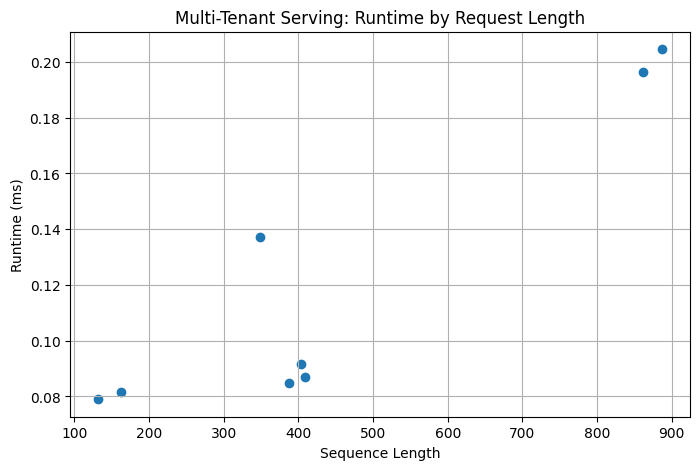

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(multitenant_df["sequence_length"], multitenant_df["runtime_ms"])
plt.xlabel("Sequence Length")
plt.ylabel("Runtime (ms)")
plt.title("Multi-Tenant Serving: Runtime by Request Length")
plt.grid(True)
plt.show()

## Scenario 2: Streaming Inference

In streaming inference, tokens arrive incrementally and the effective context grows over time. Standard attention may require repeated computation as the prefix becomes longer.

To simulate this, we process a sequence one token at a time and compute attention using the current prefix.

In [11]:
def streaming_attention(Q_seq, K_seq, V_seq):
    outputs = []

    for t in range(Q_seq.size(1)):
        Q_t = Q_seq[:, t:t+1, :]
        K_t = K_seq[:, :t+1, :]
        V_t = V_seq[:, :t+1, :]
        out_t = baseline_attention(Q_t, K_t, V_t)
        outputs.append(out_t)

    return torch.cat(outputs, dim=1)

In [12]:
def benchmark_streaming(seq_len=512, d_model=64, num_warmup=3, num_runs=10):
    Q = torch.randn(1, seq_len, d_model, device=device)
    K = torch.randn(1, seq_len, d_model, device=device)
    V = torch.randn(1, seq_len, d_model, device=device)

    for _ in range(num_warmup):
        _ = streaming_attention(Q, K, V)

    if device == "cuda":
        torch.cuda.synchronize()

    start = time.perf_counter()

    for _ in range(num_runs):
        _ = streaming_attention(Q, K, V)

    if device == "cuda":
        torch.cuda.synchronize()

    end = time.perf_counter()

    avg_ms = (end - start) * 1000 / num_runs
    return avg_ms

In [13]:
streaming_lengths = [64, 128, 256, 512]
streaming_results = []

for seq_len in streaming_lengths:
    runtime_ms = benchmark_streaming(seq_len=seq_len, d_model=64)
    streaming_results.append({
        "sequence_length": seq_len,
        "runtime_ms": runtime_ms
    })

streaming_df = pd.DataFrame(streaming_results)
streaming_df

,sequence_length,runtime_ms
0,64,7.012890
1,128,13.100754
2,256,28.908190
3,512,50.813151


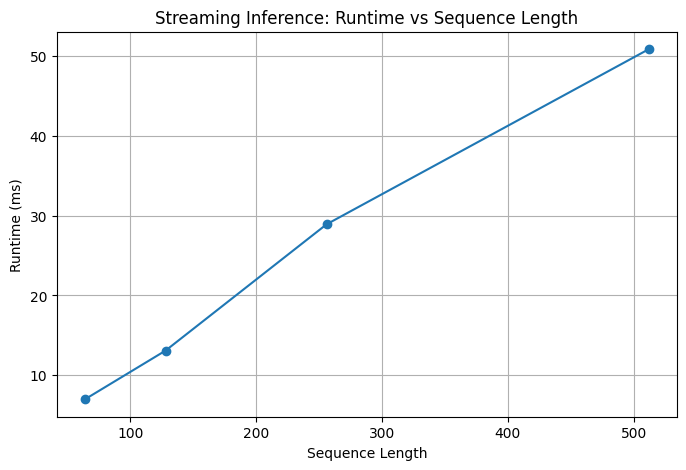

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(streaming_df["sequence_length"], streaming_df["runtime_ms"], marker="o")
plt.xlabel("Sequence Length")
plt.ylabel("Runtime (ms)")
plt.title("Streaming Inference: Runtime vs Sequence Length")
plt.grid(True)
plt.show()

## Scenario 3: Long-Context Systems

Long-context systems stress the quadratic memory and runtime behavior of standard attention. As sequence length increases, the cost of materializing the full attention matrix becomes more severe.

This experiment benchmarks standard attention over increasing sequence lengths.

In [15]:
def run_long_context_experiment(seq_lengths, batch_size=1, d_model=64):
    results = []

    for seq_len in seq_lengths:
        Q = torch.randn(batch_size, seq_len, d_model, device=device)
        K = torch.randn(batch_size, seq_len, d_model, device=device)
        V = torch.randn(batch_size, seq_len, d_model, device=device)

        runtime_ms = benchmark_runtime(baseline_attention, Q, K, V)
        peak_memory_mb = benchmark_memory(baseline_attention, Q, K, V)

        results.append({
            "sequence_length": seq_len,
            "runtime_ms": runtime_ms,
            "peak_memory_mb": peak_memory_mb
        })

    return pd.DataFrame(results)

In [16]:
long_context_lengths = [128, 256, 512, 1024, 2048]
long_context_df = run_long_context_experiment(long_context_lengths, batch_size=1, d_model=64)
long_context_df

,sequence_length,runtime_ms,peak_memory_mb
0,128,0.098252,8.625
1,256,0.092036,9.125
2,512,0.105221,10.875
3,1024,0.245072,17.375
4,2048,0.830599,42.375


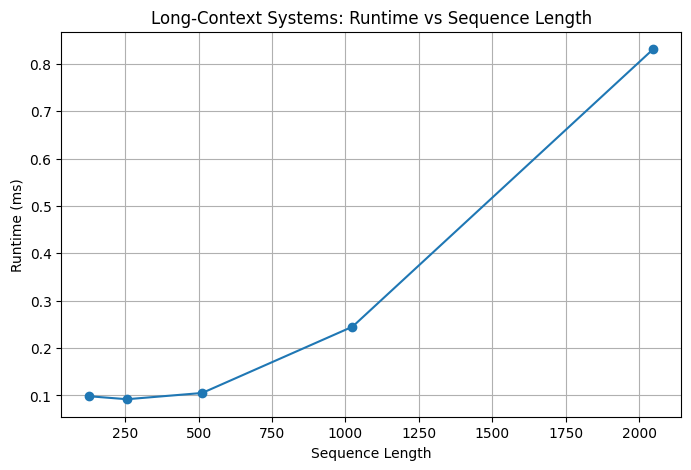

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(long_context_df["sequence_length"], long_context_df["runtime_ms"], marker="o")
plt.xlabel("Sequence Length")
plt.ylabel("Runtime (ms)")
plt.title("Long-Context Systems: Runtime vs Sequence Length")
plt.grid(True)
plt.show()

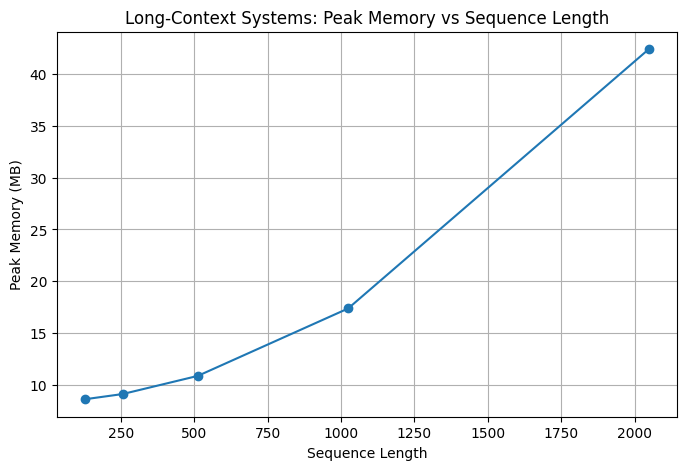

In [18]:
if long_context_df["peak_memory_mb"].notna().any():
    plt.figure(figsize=(8, 5))
    plt.plot(long_context_df["sequence_length"], long_context_df["peak_memory_mb"], marker="o")
    plt.xlabel("Sequence Length")
    plt.ylabel("Peak Memory (MB)")
    plt.title("Long-Context Systems: Peak Memory vs Sequence Length")
    plt.grid(True)
    plt.show()

## Week 1 Observations

The baseline experiments show that standard attention exhibits different limitations depending on the workload scenario.

In the multi-tenant serving simulation, requests with different sequence lengths produce heterogeneous runtime and memory behavior, illustrating the difficulty of relying on fixed execution assumptions for mixed workloads.

In the streaming inference experiment, runtime increases as the effective context grows, highlighting the repeated cost of incremental attention computation.

In the long-context experiment, both runtime and memory usage increase substantially with sequence length, reflecting the quadratic cost of standard attention.

Together, these results motivate a programmable and scenario-aware approach to memory-efficient attention execution. Rather than targeting general-purpose superiority over specialized kernels, the project focuses on settings where adaptability and customization may offer tangible benefit.

## Week 1 Deliverables Completed

- Defined the three target application scenarios:
  - Multi-tenant LLM serving
  - Streaming inference
  - Long-context systems
- Implemented a baseline scaled dot-product attention mechanism in PyTorch
- Built initial experiments for each scenario
- Collected runtime and memory measurements to characterize baseline behavior

These results establish the baseline motivation for later DSL-based transformations and adaptive attention execution strategies.